# 1 TLS Feedback Example

This example runs the delayed-feedback simulation in one function: parameter input, time evolution, expectation values, and plotting.

n_steps                 = 160
delay_steps             = 40
times[:8]             = [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35]
tls_pop[:8]           = [1.         0.9508278  0.9040735  0.85961822 0.81734889 0.77715805
 0.73894348 0.702608  ]
loop_bin_pop[:8]      = [0.         0.0245861  0.02337715 0.02222764 0.02113466 0.02009542
 0.01910729 0.01816774]
feedback_bin_pop[:8]  = [0.         0.0245861  0.02337715 0.02222764 0.02113466 0.02009542
 0.01910729 0.01816774]
delay_total_pop[:8]   = [0.         0.0245861  0.04796325 0.07019089 0.09132555 0.11142098
 0.13052826 0.148696  ]
emitted_output[:8]    = [0.         0.0245861  0.04796325 0.07019089 0.09132555 0.11142098
 0.13052826 0.148696  ]
total_excitation[:8]  = [1. 1. 1. 1. 1. 1. 1. 1.]
------------------------------------------------------------------------
final tls_pop         = 0.0062682183396359495
final delay_total_pop = 0.003853257805797705
final emitted_output  = 0.9898785238545683
final total           = 1.000000000000002
m

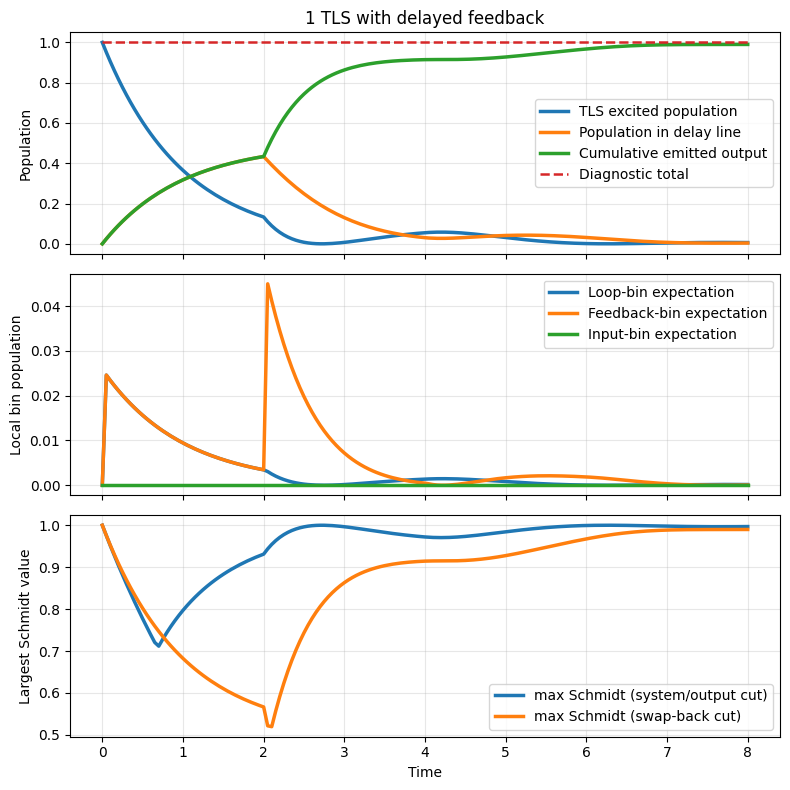

In [ ]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import wqedmps as qmps


def run_feedback_tls_example() -> tuple[
    qmps.InputParams, qmps.BinsSeempsNMar, dict[str, np.ndarray | float]
]:
    """Run the 1-TLS delayed-feedback example from inputs to observables and plots."""
    # 1. Define the physical and numerical parameters.
    params = qmps.InputParams(
        delta_t=0.05,
        tmax=8.0,
        tau=2.0,
        d_sys_total=[2],
        d_t_total=[2],
        gamma_l=0.5,
        gamma_r=0.5,
        phase=0.0,
        bond_max=18,
        atol=1e-12,
    )

    # 2. Build the initial state and local feedback Hamiltonian.
    initial_system = qmps.tls_excited()
    initial_field = qmps.wg_ground(params.d_t)
    hamiltonian = qmps.hamiltonian_1tls_feedback(params)

    # 3. Run the delayed-feedback time evolution.
    bins = qmps.t_evol_nmar_seemps(
        hamiltonian,
        initial_system,
        initial_field,
        params,
    )

    # 4. Compute expectation values of the system and field observables.
    times = np.asarray(bins.times, dtype=float)
    tls_pop = np.asarray(
        qmps.single_time_expectation(bins.system_states, qmps.tls_pop(params.d_sys)),
        dtype=float,
    )
    loop_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.loop_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    feedback_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.output_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )
    input_bin_pop = np.asarray(
        qmps.single_time_expectation(bins.input_field_states, qmps.num_op(params.d_t)),
        dtype=float,
    )

    # Reconstruct the population currently stored inside the delay line.
    delay_steps = params.delay_steps
    if delay_steps > 0:
        csum = np.cumsum(loop_bin_pop)
        delay_total_pop = csum.copy()
        if len(loop_bin_pop) > delay_steps:
            delay_total_pop[delay_steps:] = csum[delay_steps:] - csum[:-delay_steps]
    else:
        delay_total_pop = np.zeros_like(loop_bin_pop)

    # Population that has already completed the feedback cycle.
    emitted_output = np.cumsum(feedback_bin_pop)
    total_excitation = tls_pop + delay_total_pop + emitted_output

    # Track the largest Schmidt values as a simple entanglement diagnostic.
    schmidt_max = np.array(
        [
            np.max(np.asarray(s, dtype=float)) if len(s) > 0 else 0.0
            for s in bins.schmidt
        ],
        dtype=float,
    )
    schmidt_tau_max = np.array(
        [
            np.max(np.asarray(s, dtype=float)) if len(s) > 0 else 0.0
            for s in bins.schmidt_tau
        ],
        dtype=float,
    )

    observables = {
        "times": times,
        "tls_pop": tls_pop,
        "loop_bin_pop": loop_bin_pop,
        "feedback_bin_pop": feedback_bin_pop,
        "input_bin_pop": input_bin_pop,
        "delay_total_pop": delay_total_pop,
        "emitted_output": emitted_output,
        "total_excitation": total_excitation,
        "schmidt_max": schmidt_max,
        "schmidt_tau_max": schmidt_tau_max,
        "max_abs_error": float(np.max(np.abs(total_excitation - total_excitation[0]))),
    }

    # 5. Print a short numerical summary before plotting.
    print("=" * 72)
    print(f"n_steps                 = {params.steps}")
    print(f"delay_steps             = {params.delay_steps}")
    print("times[:8]             =", observables["times"][:8])
    print("tls_pop[:8]           =", observables["tls_pop"][:8])
    print("loop_bin_pop[:8]      =", observables["loop_bin_pop"][:8])
    print("feedback_bin_pop[:8]  =", observables["feedback_bin_pop"][:8])
    print("delay_total_pop[:8]   =", observables["delay_total_pop"][:8])
    print("emitted_output[:8]    =", observables["emitted_output"][:8])
    print("total_excitation[:8]  =", observables["total_excitation"][:8])
    print("-" * 72)
    print("final tls_pop         =", observables["tls_pop"][-1])
    print("final delay_total_pop =", observables["delay_total_pop"][-1])
    print("final emitted_output  =", observables["emitted_output"][-1])
    print("final total           =", observables["total_excitation"][-1])
    print("max |total-total(0)|  =", observables["max_abs_error"])
    print("=" * 72)

    # 6. Plot system population, field populations and Schmidt diagnostics.
    fig, axes = plt.subplots(3, 1, figsize=(8.0, 8.0), sharex=True)

    axes[0].plot(times, tls_pop, lw=2.5, label="TLS excited population")
    axes[0].plot(times, delay_total_pop, lw=2.5, label="Population in delay line")
    axes[0].plot(times, emitted_output, lw=2.5, label="Cumulative emitted output")
    axes[0].plot(times, total_excitation, "--", lw=1.8, label="Diagnostic total")
    axes[0].set_ylabel("Population")
    axes[0].set_title("1 TLS with delayed feedback")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(times, loop_bin_pop, lw=2.5, label="Loop-bin expectation")
    axes[1].plot(times, feedback_bin_pop, lw=2.5, label="Feedback-bin expectation")
    axes[1].plot(times, input_bin_pop, lw=2.5, label="Input-bin expectation")
    axes[1].set_ylabel("Local bin population")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(times, schmidt_max, lw=2.5, label="max Schmidt (system/output cut)")
    axes[2].plot(times, schmidt_tau_max, lw=2.5, label="max Schmidt (swap-back cut)")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Largest Schmidt value")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return params, bins, observables


params, bins, observables = run_feedback_tls_example()
